# **TRABAJO PRÁCTICO 9 - SANTIAGO VOLIO**

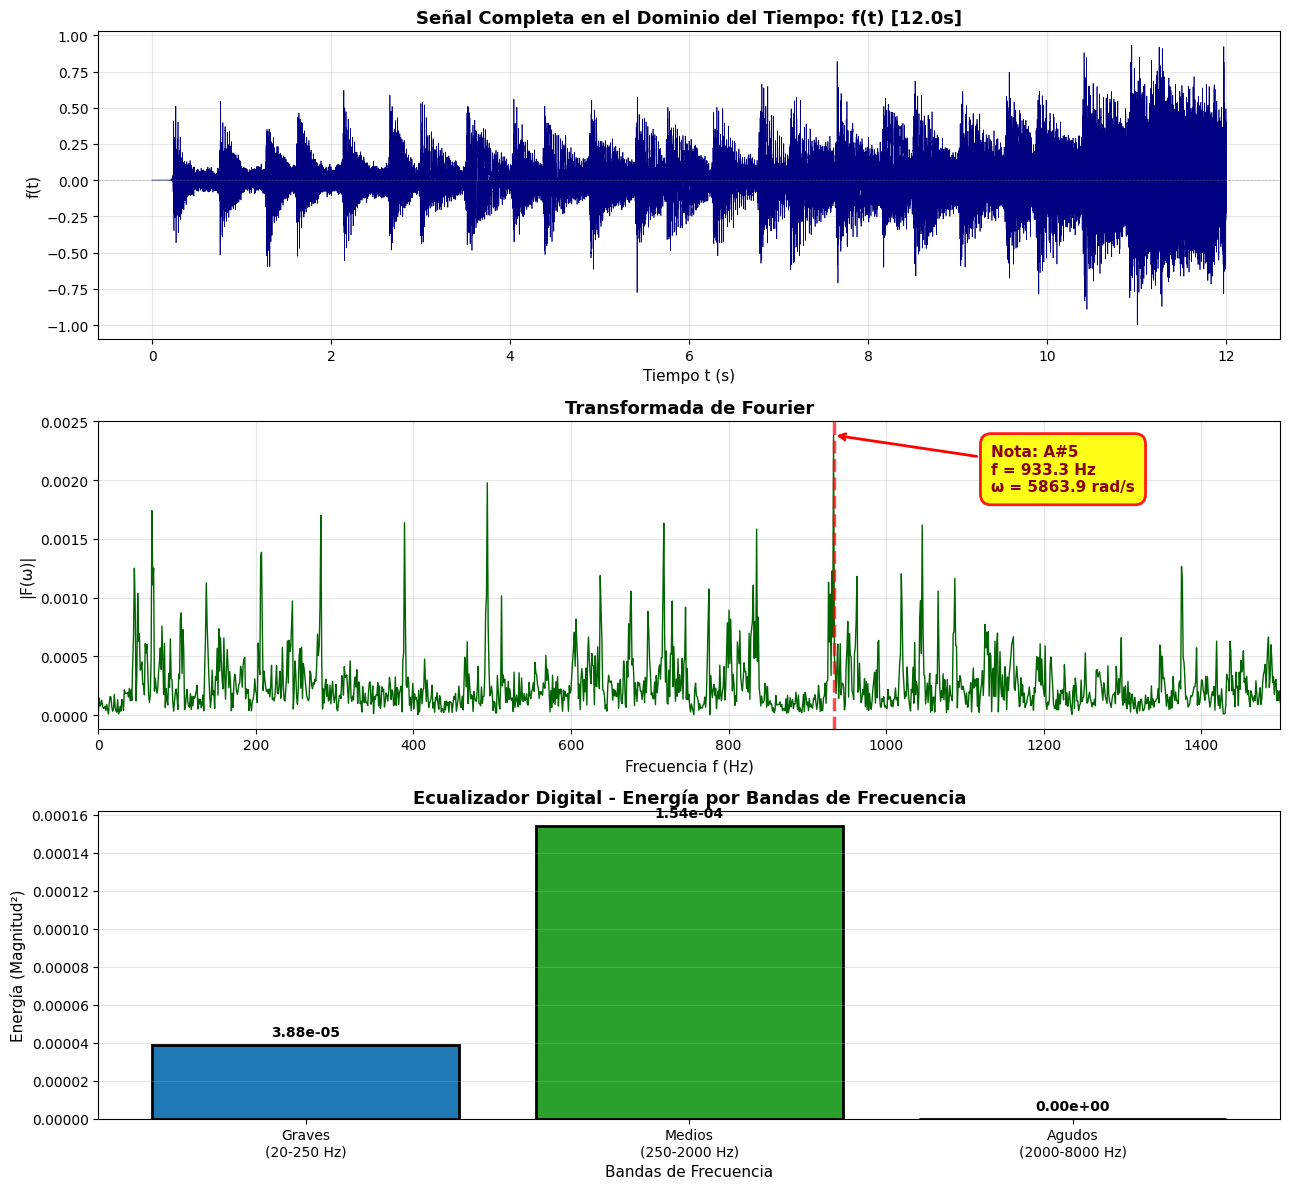

-------------------------------------------------------------------------------------
Energías por banda de frecuencia
-------------------------------------------------------------------------------------
Energía en Graves (20-250 Hz): 3.88e-05
Energía en Medios (250-2000 Hz): 1.54e-04
Energía en Agudos (2000-8000 Hz): 0.00e+00
-------------------------------------------------------------------------------------
Distribución porcentual:
-------------------------------------------------------------------------------------
Graves: 20.1%
Medios: 79.9%
Agudos: 0.0%


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

def transformada_fourier_clasica(signal, time, omega_max=10000):
    dt = time[1] - time[0]
    omegas = np.linspace(0, omega_max, 1500)
    F_omega = []

    for omega in omegas:
        suma_compleja = 0
        for n in range(0, len(signal), 50):
            t_n = time[n]
            suma_compleja += signal[n] * np.exp(-1j * omega * t_n) * dt

        F_omega.append(suma_compleja)

    F_omega = np.array(F_omega)
    magnitudes = np.abs(F_omega)
    frecuencias_hz = omegas / (2 * np.pi)

    return frecuencias_hz, magnitudes, omegas

def calcular_energia_bandas(frecuencias, magnitudes):
    """Calcula la energía en tres bandas de frecuencia: Graves, Medios y Agudos."""
    # Definir bandas
    graves_min, graves_max = 20, 250
    medios_min, medios_max = 250, 2000
    agudos_min, agudos_max = 2000, 8000

    # Energias
    energia_graves = 0
    energia_medios = 0
    energia_agudos = 0

    for i, freq in enumerate(frecuencias):
        if graves_min <= freq <= graves_max:
            energia_graves += magnitudes[i]**2
        elif medios_min <= freq <= medios_max:
            energia_medios += magnitudes[i]**2
        elif agudos_min <= freq <= agudos_max:
            energia_agudos += magnitudes[i]**2

    return energia_graves, energia_medios, energia_agudos

def frequency_to_note(freq):
    A4 = 440.0
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    semitones = 12 * np.log2(freq / A4)
    note_number = int(round(semitones))
    octave = 4 + (note_number + 9) // 12
    note_index = (note_number + 9) % 12
    return note_names[note_index] + str(octave)

# Cargar archivo
sample_rate, audio_data = wavfile.read('cancion.wav')

if len(audio_data.shape) == 2:
    audio_data = audio_data[:, 0]

audio_data = audio_data.astype(float)
audio_data = audio_data / np.max(np.abs(audio_data))
segundos_a_analizar = 12.0
num_muestras = int(sample_rate * segundos_a_analizar)
audio_segment = audio_data[:num_muestras]
time = np.arange(len(audio_segment)) / sample_rate
frecuencias_hz, magnitudes, omegas = transformada_fourier_clasica(audio_segment, time)

# Encontrar frecuencia fundamental
peak_index = np.argmax(magnitudes[20:]) + 20
fundamental_freq = frecuencias_hz[peak_index]
fundamental_omega = omegas[peak_index]
detected_note = frequency_to_note(fundamental_freq)

# Calcular energía por bandas
energia_graves, energia_medios, energia_agudos = calcular_energia_bandas(frecuencias_hz, magnitudes)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 12))
ax1.plot(time, audio_segment, linewidth=0.5, color='navy')
ax1.set_xlabel('Tiempo t (s)', fontsize=11)
ax1.set_ylabel('f(t)', fontsize=11)
ax1.set_title(f'Señal Completa en el Dominio del Tiempo: f(t) [{segundos_a_analizar}s]',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)


ax2.plot(frecuencias_hz, magnitudes, linewidth=1, color='darkgreen')
ax2.axvline(fundamental_freq, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
ax2.set_xlabel('Frecuencia f (Hz)', fontsize=11)
ax2.set_ylabel('|F(ω)|', fontsize=11)
ax2.set_title('Transformada de Fourier', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1500)
ax2.grid(True, alpha=0.3)

ax2.annotate(f'Nota: {detected_note}\nf = {fundamental_freq:.1f} Hz\nω = {fundamental_omega:.1f} rad/s',
            xy=(fundamental_freq, magnitudes[peak_index]),
            xytext=(fundamental_freq + 200, magnitudes[peak_index] * 0.8),
            fontsize=11, fontweight='bold', color='darkred',
            bbox=dict(boxstyle='round,pad=0.7', facecolor='yellow', alpha=0.9,
                     edgecolor='red', linewidth=2),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

bandas = ['Graves\n(20-250 Hz)', 'Medios\n(250-2000 Hz)', 'Agudos\n(2000-8000 Hz)']
energias = [energia_graves, energia_medios, energia_agudos]
colores = ['#1f77b4', '#2ca02c', '#d62728']

bars = ax3.bar(bandas, energias, color=colores, edgecolor='black', linewidth=2)
ax3.set_xlabel('Bandas de Frecuencia', fontsize=11)
ax3.set_ylabel('Energía (Magnitud²)', fontsize=11)
ax3.set_title('Ecualizador Digital - Energía por Bandas de Frecuencia',
              fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores numéricos en las barras
for bar, energia in zip(bars, energias):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(energias)*0.02,
             f'{energia:.2e}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fourier_clasica_guitar_con_ecualizador.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimir resultados en consola
print("-"*85)
print("Energías por banda de frecuencia")
print("-"*85)
print(f"Energía en Graves (20-250 Hz): {energia_graves:.2e}")
print(f"Energía en Medios (250-2000 Hz): {energia_medios:.2e}")
print(f"Energía en Agudos (2000-8000 Hz): {energia_agudos:.2e}")
print("-"*85)
print("Distribución porcentual:")
print("-"*85)
total = energia_graves + energia_medios + energia_agudos
print(f"Graves: {100*energia_graves/total:.1f}%")
print(f"Medios: {100*energia_medios/total:.1f}%")
print(f"Agudos: {100*energia_agudos/total:.1f}%")